------------------------------------------------------------
## SECTION 1: Imports and Configuration
------------------------------------------------------------

# CAPEv2 Log Parsing and Behavioral Feature Extraction

## Deliverable 2: Automated Dynamic Analysis Signature Generation

This notebook implements a comprehensive pipeline for:
1. Parsing CAPEv2 report.json files from sandbox execution
2. Extracting structured behavioral features
3. Converting behaviors into representations suitable for LLM analysis and signature generation

**Input**: CAPEv2 JSON reports in `data/public_small_reports/public_small_reports/`
**Output**: Structured feature dataset for signature generation

In [22]:
# Import required libraries
import json
import os
import glob
import pandas as pd
from tqdm import tqdm
from collections import Counter, defaultdict
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configure paths
PROJECT_ROOT = Path('../').resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'public_small_reports' / 'public_small_reports'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

# Create processed directory if it doesn't exist
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data path: {DATA_PATH}")
print(f"Processed output path: {PROCESSED_DIR}")

# Load preprocessed samples from data_acquisition.ipynb (includes family labels)
preprocessed_path = PROJECT_ROOT / 'data' / 'preprocessed_samples.csv'
if preprocessed_path.exists():
    df_samples = pd.read_csv(preprocessed_path)
    print(f"\n✓ Loaded preprocessed samples: {len(df_samples)} samples")
    print(f"  Columns: {df_samples.columns.tolist()}")
    print(f"  Families: {df_samples['classification_family'].nunique()} unique")
    
    # Build report file paths from json_path column
    report_files = [str(DATA_PATH / f"{row['sha256']}.json") for _, row in df_samples.iterrows()]
    # Filter to only existing files
    report_files_valid = [f for f in report_files if os.path.exists(f)]
    print(f"  Valid JSON files: {len(report_files_valid)}/{len(report_files)}")
    
    # Create mapping from hash to family/type for later use
    hash_to_family = dict(zip(df_samples['sha256'], df_samples['classification_family']))
    hash_to_type = dict(zip(df_samples['sha256'], df_samples['classification_type']))
    
    report_files = report_files_valid
else:
    print("⚠ Preprocessed samples not found, falling back to raw glob...")
    report_files = sorted(glob.glob(str(DATA_PATH / '*.json')))
    hash_to_family = {}
    hash_to_type = {}

print(f"\nFound {len(report_files)} CAPEv2 reports to process")

Data path: C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\public_small_reports\public_small_reports
Processed output path: C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed

✓ Loaded preprocessed samples: 48976 samples
  Columns: ['sha256', 'classification_family', 'classification_type', 'date', 'json_path']
  Families: 10 unique
  Valid JSON files: 48976/48976

Found 48976 CAPEv2 reports to process


------------------------------------------------------------
## SECTION 2: JSON Structure Exploration
------------------------------------------------------------

Explore the structure of a sample CAPEv2 report to understand available fields:

In [23]:
# Load and inspect a sample report
if report_files:
    sample_report_path = report_files[0]
    with open(sample_report_path, 'r') as f:
        sample_report = json.load(f)
    
    print(f"Sample report: {os.path.basename(sample_report_path)}")
    print(f"\nTop-level keys: {list(sample_report.keys())}")
    
    # Inspect behavior section
    if 'behavior' in sample_report:
        print(f"\nbehavior keys: {list(sample_report['behavior'].keys())}")
        
        if 'summary' in sample_report['behavior']:
            behavior_summary = sample_report['behavior']['summary']
            print(f"\nbehavior.summary keys:")
            for key in behavior_summary.keys():
                val = behavior_summary[key]
                if isinstance(val, list):
                    print(f"  - {key}: list with {len(val)} items")
                else:
                    print(f"  - {key}: {type(val).__name__}")
    
    # Inspect static section
    if 'static' in sample_report:
        print(f"\nstatic keys: {list(sample_report['static'].keys())}")
        if 'pe' in sample_report['static']:
            print(f"static.pe keys: {list(sample_report['static']['pe'].keys())[:10]}...")
else:
    print("No reports found!")

Sample report: 00003d128a7eb859f65f5780d8fa2b5e52d472665678bf6e388e857fbaed773a.json

Top-level keys: ['behavior', 'static']

behavior keys: ['summary']

behavior.summary keys:
  - keys: list with 137 items
  - resolved_apis: list with 477 items
  - executed_commands: list with 11 items
  - write_keys: list with 1 items
  - files: list with 46 items
  - read_files: list with 22 items
  - started_services: list with 0 items
  - created_services: list with 0 items
  - write_files: list with 9 items
  - delete_keys: list with 0 items
  - read_keys: list with 70 items
  - delete_files: list with 9 items
  - mutexes: list with 9 items

static keys: ['pe']
static.pe keys: ['icon_hash', 'sections', 'peid_signatures', 'entrypoint', 'exports', 'overlay', 'digital_signers', 'imphash', 'reported_checksum', 'icon']...


------------------------------------------------------------
## SECTION 3: CAPEv2 Log Parser
------------------------------------------------------------

Implement a robust parser to extract behavioral features from CAPEv2 reports.

In [24]:
def parse_cape_report(filepath: str) -> dict:
    """
    Parse a CAPEv2 report and extract structured behavioral features.
    
    Args:
        filepath: Path to the CAPEv2 report.json file
    
    Returns:
        Dictionary containing extracted behavioral features:
        - api_calls: List of API call names
        - api_freq: Counter of API call frequencies
        - files: List of file operations
        - registry: List of registry operations
        - domains: List of accessed domains
        - ips: List of accessed IPs
        - http_requests: List of HTTP requests
        - processes: List of process names
    """
    
    features = {
        'api_calls': [],
        'api_freq': Counter(),
        'files': [],
        'registry': [],
        'domains': [],
        'ips': [],
        'http_requests': [],
        'processes': [],
        'mutexes': [],
        'executed_commands': []
    }
    
    try:
        with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
            report = json.load(f)
    except (json.JSONDecodeError, IOError) as e:
        print(f"Error reading {filepath}: {e}")
        return features
    
    # Extract from behavior.summary section
    behavior = report.get('behavior', {})
    summary = behavior.get('summary', {})
    
    # 1. API CALLS - Extract from resolved_apis
    resolved_apis = summary.get('resolved_apis', [])
    if isinstance(resolved_apis, list):
        features['api_calls'] = resolved_apis.copy()
        features['api_freq'] = Counter(resolved_apis)
    
    # 2. FILE SYSTEM ACTIVITY - Combine file operations
    write_files = summary.get('write_files', [])
    delete_files = summary.get('delete_files', [])
    read_files = summary.get('read_files', [])
    files_summary = summary.get('files', [])
    
    file_ops = []
    if isinstance(write_files, list):
        file_ops.extend([(f, 'write') for f in write_files])
    if isinstance(delete_files, list):
        file_ops.extend([(f, 'delete') for f in delete_files])
    if isinstance(read_files, list):
        file_ops.extend([(f, 'read') for f in read_files])
    if isinstance(files_summary, list):
        file_ops.extend([(f, 'accessed') for f in files_summary])
    
    features['files'] = file_ops
    
    # 3. REGISTRY ACTIVITY
    write_keys = summary.get('write_keys', [])
    delete_keys = summary.get('delete_keys', [])
    read_keys = summary.get('read_keys', [])
    keys = summary.get('keys', [])
    
    registry_ops = []
    if isinstance(write_keys, list):
        registry_ops.extend([(k, 'write') for k in write_keys])
    if isinstance(delete_keys, list):
        registry_ops.extend([(k, 'delete') for k in delete_keys])
    if isinstance(read_keys, list):
        registry_ops.extend([(k, 'read') for k in read_keys])
    if isinstance(keys, list):
        registry_ops.extend([(k, 'accessed') for k in keys])
    
    features['registry'] = registry_ops
    
    # 4. PROCESS INFORMATION
    # Extract process names from various sources
    executed_commands = summary.get('executed_commands', [])
    if isinstance(executed_commands, list):
        features['executed_commands'] = executed_commands.copy()
        # Extract process names from commands
        for cmd in executed_commands:
            if isinstance(cmd, str) and cmd.strip():
                proc_name = cmd.split()[0] if cmd.split() else cmd
                features['processes'].append(proc_name)
    
    # 5. MUTEXES
    mutexes = summary.get('mutexes', [])
    if isinstance(mutexes, list):
        features['mutexes'] = mutexes.copy()
    
    # 6. NETWORK ACTIVITY (if available in report)
    network = report.get('network', {})
    
    # Extract DNS requests
    dns_requests = network.get('dns', [])
    if isinstance(dns_requests, list):
        for dns in dns_requests:
            if isinstance(dns, dict):
                request = dns.get('request', '')
                if request:
                    features['domains'].append(request)
    
    # Extract TCP connections
    tcp_connections = network.get('tcp', [])
    if isinstance(tcp_connections, list):
        for tcp in tcp_connections:
            if isinstance(tcp, dict):
                dst = tcp.get('dst', '')
                if dst:
                    features['ips'].append(dst)
    
    # Extract HTTP requests
    http_requests = network.get('http', [])
    if isinstance(http_requests, list):
        for http in http_requests:
            if isinstance(http, dict):
                uri = http.get('uri', '')
                if uri:
                    features['http_requests'].append(uri)
    
    # Remove duplicates while preserving list type
    features['domains'] = list(set(features['domains']))
    features['ips'] = list(set(features['ips']))
    features['http_requests'] = list(set(features['http_requests']))
    features['processes'] = list(set(features['processes']))
    
    return features


# Test the parser on a sample report
print("Testing parser on sample report...")
if report_files:
    sample_features = parse_cape_report(report_files[0])
    print(f"\nExtracted features:")
    print(f"  - API calls: {len(sample_features['api_calls'])}")
    print(f"  - Unique APIs: {len(sample_features['api_freq'])}")
    print(f"  - Files: {len(sample_features['files'])}")
    print(f"  - Registry keys: {len(sample_features['registry'])}")
    print(f"  - Domains: {len(sample_features['domains'])}")
    print(f"  - IPs: {len(sample_features['ips'])}")
    print(f"  - HTTP requests: {len(sample_features['http_requests'])}")
    print(f"  - Processes: {len(sample_features['processes'])}")
    print(f"  - Mutexes: {len(sample_features['mutexes'])}")
    print(f"\nSample API calls: {sample_features['api_calls'][:5]}")
    print(f"Top 5 APIs: {sample_features['api_freq'].most_common(5)}")

Testing parser on sample report...

Extracted features:
  - API calls: 477
  - Unique APIs: 477
  - Files: 86
  - Registry keys: 208
  - Domains: 0
  - IPs: 0
  - HTTP requests: 0
  - Processes: 9
  - Mutexes: 9

Sample API calls: ['kernel32.dll.FlsAlloc', 'kernel32.dll.FlsGetValue', 'kernel32.dll.FlsSetValue', 'kernel32.dll.FlsFree', 'kernelbase.dll.InitializeCriticalSectionAndSpinCount']
Top 5 APIs: [('kernel32.dll.FlsAlloc', 1), ('kernel32.dll.FlsGetValue', 1), ('kernel32.dll.FlsSetValue', 1), ('kernel32.dll.FlsFree', 1), ('kernelbase.dll.InitializeCriticalSectionAndSpinCount', 1)]


------------------------------------------------------------
## SECTION 4: Dataset-Level Feature Extraction
------------------------------------------------------------

Extract features from all reports and create a structured dataset:

In [25]:
# Extract features from all reports
all_features = []
report_hashes = []

print(f"Processing {len(report_files)} reports...")

for report_path in tqdm(report_files, desc="Extracting features"):
    features = parse_cape_report(report_path)
    all_features.append(features)
    # Extract hash from filename
    report_hash = os.path.splitext(os.path.basename(report_path))[0]
    report_hashes.append(report_hash)

print(f"\nSuccessfully extracted features from {len(all_features)} reports")

Processing 48976 reports...


Extracting features: 100%|██████████| 48976/48976 [01:17<00:00, 630.75it/s]


Successfully extracted features from 48976 reports


In [26]:
# Create feature matrix with aggregated metrics and family labels
feature_rows = []

for idx, (report_hash, features) in enumerate(zip(report_hashes, all_features)):
    row = {
        'report_hash': report_hash,
        # Add family and type labels from preprocessed data
        'family': hash_to_family.get(report_hash, 'unknown'),
        'type': hash_to_type.get(report_hash, 'unknown'),
        # API call statistics
        'num_api_calls': len(features['api_calls']),
        'unique_api_count': len(features['api_freq']),
        'api_entropy': sum(v * (-v / len(features['api_calls'])) for v in features['api_freq'].values()) if features['api_calls'] else 0,
        # File operations
        'num_files': len(features['files']),
        'num_write_files': sum(1 for f, op in features['files'] if op == 'write'),
        'num_delete_files': sum(1 for f, op in features['files'] if op == 'delete'),
        # Registry operations
        'num_registry_keys': len(features['registry']),
        'num_write_registry': sum(1 for r, op in features['registry'] if op == 'write'),
        'num_delete_registry': sum(1 for r, op in features['registry'] if op == 'delete'),
        # Network activity
        'num_domains': len(features['domains']),
        'num_ips': len(features['ips']),
        'num_http_requests': len(features['http_requests']),
        'has_network': len(features['domains']) > 0 or len(features['ips']) > 0,
        # Process and system activity
        'num_processes': len(features['processes']),
        'num_mutexes': len(features['mutexes']),
        'num_commands': len(features['executed_commands']),
    }
    feature_rows.append(row)

# Create DataFrame
df_features = pd.DataFrame(feature_rows)

print(f"\nFeature matrix shape: {df_features.shape}")
print(f"\nSamples per family:")
print(df_features['family'].value_counts())
print(f"\nFeature statistics:")
print(df_features.describe())


Feature matrix shape: (48976, 19)

Samples per family:
family
Emotet      14429
Swisyn      12591
Qakbot       4895
Trickbot     4202
Lokibot      4191
njRAT        3372
Zeus         2594
Ursnif       1343
Adload        704
HarHar        655
Name: count, dtype: int64

Feature statistics:
       num_api_calls  unique_api_count  api_entropy      num_files  \
count   48976.000000      48976.000000  48976.00000   48976.000000   
mean      175.432783        175.432783     -0.99608     116.864525   
std       131.491073        131.491073      0.06249     971.335932   
min         0.000000          0.000000     -1.00000       0.000000   
25%        91.000000         91.000000     -1.00000      29.000000   
50%       136.000000        136.000000     -1.00000      50.000000   
75%       224.000000        224.000000     -1.00000      85.000000   
max      1969.000000       1969.000000      0.00000  129887.000000   

       num_write_files  num_delete_files  num_registry_keys  \
count     48976.

------------------------------------------------------------
## SECTION 5: Feature Engineering for Signature Generation
------------------------------------------------------------

Create behavior patterns and indicators for signature generation:

In [27]:
# Define signature indicators based on common malware behaviors

# Suspicious API calls that indicate malicious behavior
SUSPICIOUS_APIS = {
    # Process manipulation
    'CreateRemoteThread', 'WriteProcessMemory', 'VirtualAllocEx', 'SetWindowsHookEx',
    'CreateProcessA', 'CreateProcessW', 'CreateProcessAsUserA', 'CreateProcessAsUserW',
    # File operations
    'CopyFileA', 'CopyFileW', 'MoveFileA', 'MoveFileW', 'DeleteFileA', 'DeleteFileW',
    # Registry operations
    'RegSetValueEx', 'RegCreateKeyEx', 'RegDeleteKeyEx', 'RegDeleteValueA', 'RegDeleteValueW',
    # Network operations
    'InternetOpenA', 'InternetOpenW', 'InternetOpenUrlA', 'InternetOpenUrlW',
    'InternetConnectA', 'InternetConnectW', 'HttpOpenRequestA', 'HttpOpenRequestW',
    'InternetReadFile', 'InternetWriteFile',
    # DLL/Code injection
    'LoadLibraryA', 'LoadLibraryW', 'LoadLibraryExA', 'LoadLibraryExW',
    'GetProcAddress', 'GetModuleHandleA', 'GetModuleHandleW',
    # Persistence
    'ShellExecuteA', 'ShellExecuteW', 'WinExec'
}

def extract_signature_features(features_dict: dict, all_features_list: list, report_idx: int) -> dict:
    """
    Extract signature generation features from parsed report features.
    
    Args:
        features_dict: Dictionary of features for a single report
        all_features_list: List of all features (for global statistics)
        report_idx: Index of this report in the all_features_list
    
    Returns:
        Dictionary with signature indicators
    """
    
    api_calls = features_dict['api_calls']
    api_freq = features_dict['api_freq']
    files = features_dict['files']
    registry = features_dict['registry']
    domains = features_dict['domains']
    http_requests = features_dict['http_requests']
    
    signature_features = {}
    
    # Top N most frequent APIs
    top_apis = [api for api, count in api_freq.most_common(10)]
    signature_features['top_apis'] = top_apis
    
    # Suspicious API presence
    suspicious_apis = [api for api in api_calls if api in SUSPICIOUS_APIS]
    signature_features['suspicious_apis'] = list(set(suspicious_apis))
    signature_features['has_suspicious_apis'] = len(suspicious_apis) > 0
    
    # Behavioral indicators
    signature_features['has_network'] = len(domains) > 0 or len(http_requests) > 0
    signature_features['drops_files'] = any(op == 'write' for f, op in files)
    signature_features['registry_modification'] = any(op == 'write' for r, op in registry)
    signature_features['process_injection'] = any(api in api_calls for api in 
                                                    ['WriteProcessMemory', 'VirtualAllocEx', 'CreateRemoteThread'])
    signature_features['dlopen_or_hook'] = any(api in api_calls for api in 
                                                 ['LoadLibraryA', 'LoadLibraryW', 'SetWindowsHookEx'])
    signature_features['shell_execute'] = any(api in api_calls for api in 
                                                ['ShellExecuteA', 'ShellExecuteW', 'WinExec', 'CreateProcessA', 'CreateProcessW'])
    
    # Advanced behavioral patterns
    signature_features['has_file_dropper'] = any(op == 'write' for f, op in files) and len(domains) > 0
    signature_features['has_c2_communication'] = len(http_requests) > 0 and any(api in api_calls for api in 
                                                                                   ['InternetOpenA', 'InternetOpenW'])
    signature_features['persistence_attempt'] = signature_features['registry_modification'] or \
                                                  any('StartUp' in r or 'Run' in r for r, op in registry)
    
    # Count and categorize behaviors
    signature_features['behavior_count'] = sum([
        signature_features['has_network'],
        signature_features['drops_files'],
        signature_features['registry_modification'],
        signature_features['process_injection'],
        signature_features['dlopen_or_hook'],
        signature_features['shell_execute']
    ])
    
    return signature_features


# Extract signature features for all reports
print("Extracting signature generation features...")
signature_features_list = []

for idx, features in enumerate(tqdm(all_features, desc="Processing signature features")):
    sig_features = extract_signature_features(features, all_features, idx)
    signature_features_list.append(sig_features)

print(f"\nExtracted signature features for {len(signature_features_list)} reports")

Extracting signature generation features...


Processing signature features: 100%|██████████| 48976/48976 [00:04<00:00, 11382.35it/s]


Extracted signature features for 48976 reports


In [28]:
# Add signature features to the main DataFrame
df_signature_indicators = pd.DataFrame(signature_features_list)

# Flatten the list-type columns for display
df_signature_indicators['num_suspicious_apis'] = df_signature_indicators['suspicious_apis'].apply(len)
df_signature_indicators['num_top_apis'] = df_signature_indicators['top_apis'].apply(len)

# Combine with main features
df_combined = pd.concat([
    df_features,
    df_signature_indicators[['has_suspicious_apis', 'has_network', 'drops_files', 
                             'registry_modification', 'process_injection', 'dlopen_or_hook',
                             'shell_execute', 'has_file_dropper', 'has_c2_communication',
                             'persistence_attempt', 'behavior_count', 'num_suspicious_apis']]
], axis=1)

print(f"\nCombined feature matrix shape: {df_combined.shape}")
print(f"\nBehavioral indicators summary:")
print(df_combined[['has_network', 'drops_files', 'registry_modification', 'process_injection',
                  'has_suspicious_apis', 'behavior_count']].sum())
print(f"\nFirst few rows:")
print(df_combined.head())


Combined feature matrix shape: (48976, 31)

Behavioral indicators summary:
has_network                  0
has_network                  0
drops_files              41521
registry_modification    33647
process_injection            0
has_suspicious_apis          0
behavior_count           75168
dtype: int64

First few rows:
                                         report_hash  family    type  \
0  00003d128a7eb859f65f5780d8fa2b5e52d472665678bf...  Qakbot  banker   
1  0000698621e473a0828c1c957873e7d086f2d90eebc6a3...  Swisyn  trojan   
2  0000a65749f5902c4d82ffa701198038f0b4870b00a27c...  Qakbot  banker   
3  0001770a2a6e888a123775fc24d8a4ffccc5c8191c1c2a...  Emotet  banker   
4  000376a4b234f57ae0f1fb959817486040d7d8d8be1fbc...  Emotet  banker   

   num_api_calls  unique_api_count  api_entropy  num_files  num_write_files  \
0            477               477         -1.0         86                9   
1            136               136         -1.0         50                2   
2      

------------------------------------------------------------
## SECTION 6: Save Processed Features
------------------------------------------------------------

Save the processed features and create supplementary data for analysis:

In [29]:
# Save main feature DataFrame
output_path = PROCESSED_DIR / 'behavior_features.csv'
df_combined.to_csv(output_path, index=False)
print(f"Saved combined features to: {output_path}")

# Save detailed behavioral data (with list columns preserved)
detail_output = PROCESSED_DIR / 'behavior_details.json'
detailed_data = []

for idx, (report_hash, features, sig_features) in enumerate(zip(report_hashes, all_features, signature_features_list)):
    record = {
        'report_hash': report_hash,
        'api_calls': features['api_calls'][:100],  # Limit to first 100 for readability
        'top_apis': sig_features['top_apis'],
        'suspicious_apis': sig_features['suspicious_apis'],
        'domains': features['domains'],
        'http_requests': features['http_requests'],
        'processes': features['processes'],
        'mutexes': features['mutexes'][:20],  # Limit to first 20
    }
    detailed_data.append(record)

with open(detail_output, 'w') as f:
    json.dump(detailed_data, f, indent=2)
print(f"Saved detailed behavioral data to: {detail_output}")

Saved combined features to: C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\behavior_features.csv
Saved detailed behavioral data to: C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\behavior_details.json


In [30]:
# Generate summary statistics
print("\n" + "="*60)
print("FEATURE EXTRACTION SUMMARY")
print("="*60)

print(f"\nTotal reports processed: {len(report_hashes)}")
print(f"\nAPI Call Statistics:")
print(f"  - Mean API calls per sample: {df_combined['num_api_calls'].mean():.1f}")
print(f"  - Mean unique APIs per sample: {df_combined['unique_api_count'].mean():.1f}")
print(f"  - Max API calls in single sample: {df_combined['num_api_calls'].max()}")

print(f"\nFile Operations:")
print(f"  - Samples with file writes: {(df_combined['num_write_files'] > 0).sum()}")
print(f"  - Mean files written per sample: {df_combined['num_write_files'].mean():.1f}")

print(f"\nRegistry Operations:")
print(f"  - Samples with registry writes: {(df_combined['num_write_registry'] > 0).sum()}")
print(f"  - Mean registry modifications per sample: {df_combined['num_write_registry'].mean():.1f}")

print(f"\nNetwork Activity:")
print(f"  - Samples with network activity: {df_combined['has_network'].sum()}")
print(f"  - Samples with HTTP requests: {(df_combined['num_http_requests'] > 0).sum()}")

print(f"\nMalicious Indicators:")
print(f"  - Samples with suspicious APIs: {df_combined['has_suspicious_apis'].sum()}")
print(f"  - Samples with process injection: {df_combined['process_injection'].sum()}")
print(f"  - Samples attempting persistence: {df_combined['persistence_attempt'].sum()}")
print(f"  - Samples with C2 communication patterns: {df_combined['has_c2_communication'].sum()}")

print(f"\nOutput Files:")
print(f"  - {output_path}")
print(f"  - {detail_output}")
print("\n" + "="*60)


FEATURE EXTRACTION SUMMARY

Total reports processed: 48976

API Call Statistics:
  - Mean API calls per sample: 175.4
  - Mean unique APIs per sample: 175.4
  - Max API calls in single sample: 1969

File Operations:
  - Samples with file writes: 41521
  - Mean files written per sample: 3.8

Registry Operations:
  - Samples with registry writes: 33647
  - Mean registry modifications per sample: 11.4

Network Activity:
  - Samples with network activity: has_network    0
has_network    0
dtype: int64
  - Samples with HTTP requests: 0

Malicious Indicators:
  - Samples with suspicious APIs: 0
  - Samples with process injection: 0
  - Samples attempting persistence: 36326
  - Samples with C2 communication patterns: 0

Output Files:
  - C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\behavior_features.csv
  - C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\behavior_details.json


------------------------------------------------------------
## SECTION 7: Data Visualization & Analysis
------------------------------------------------------------

Analyze and visualize the extracted behavioral features:

In [31]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configure plotting style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("Visualization libraries loaded successfully")

Visualization libraries loaded successfully


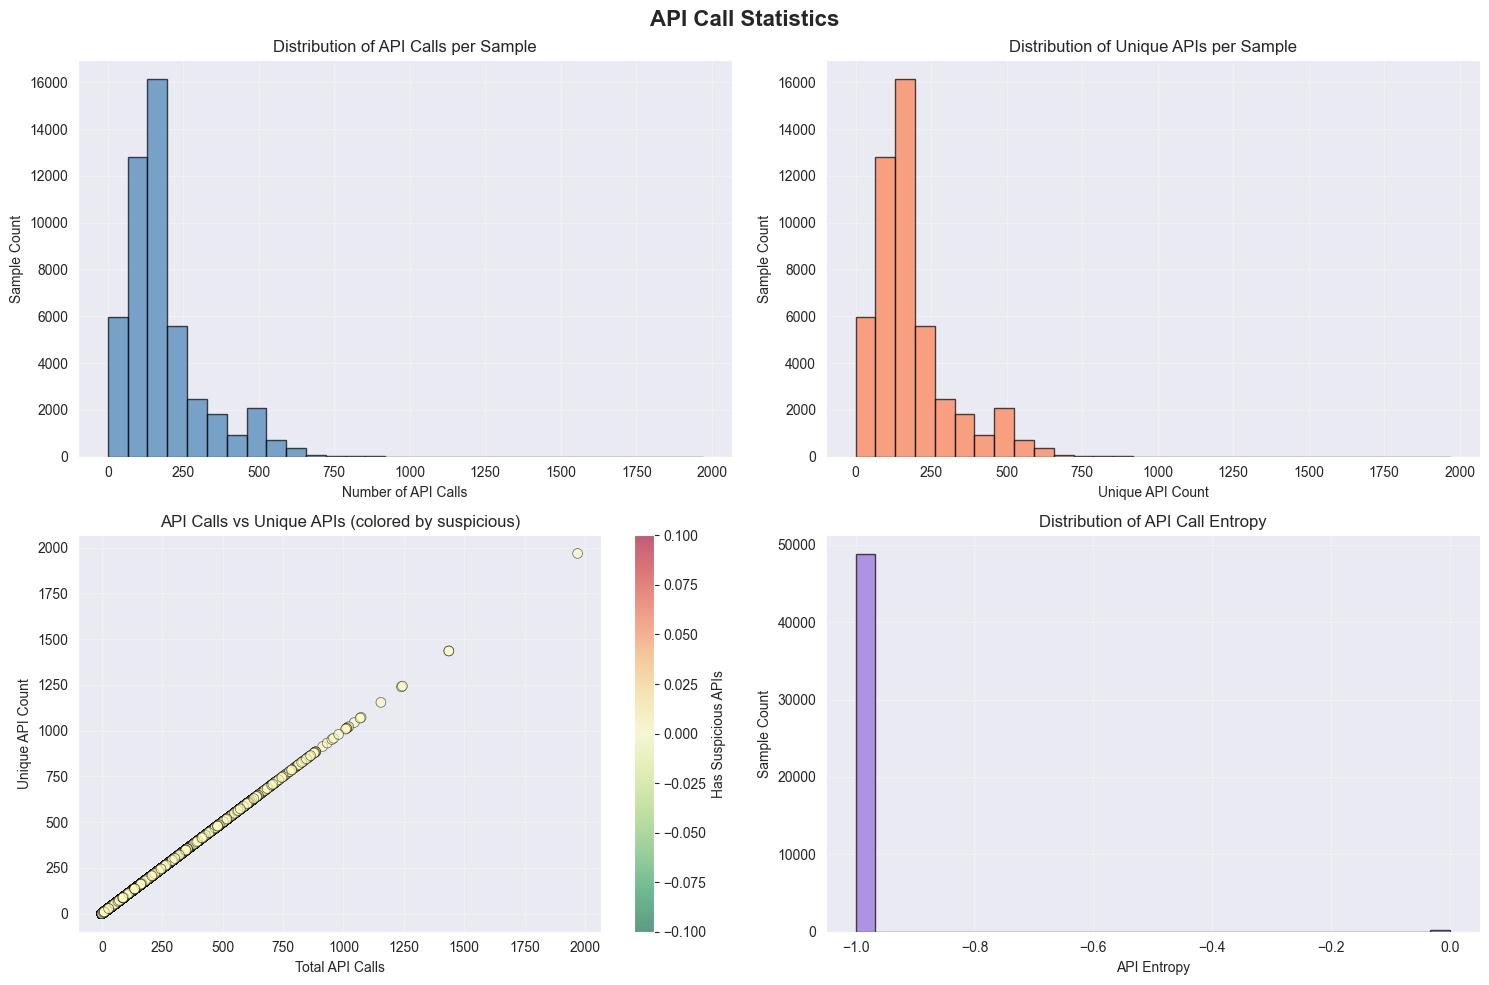

✓ API Call Statistics visualization complete


In [32]:
# Create visualization 1: API Call Distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('API Call Statistics', fontsize=16, fontweight='bold')

# API calls histogram
axes[0, 0].hist(df_combined['num_api_calls'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Number of API Calls')
axes[0, 0].set_ylabel('Sample Count')
axes[0, 0].set_title('Distribution of API Calls per Sample')
axes[0, 0].grid(alpha=0.3)

# Unique APIs histogram
axes[0, 1].hist(df_combined['unique_api_count'], bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Unique API Count')
axes[0, 1].set_ylabel('Sample Count')
axes[0, 1].set_title('Distribution of Unique APIs per Sample')
axes[0, 1].grid(alpha=0.3)

# Scatter: Total APIs vs Unique APIs
scatter = axes[1, 0].scatter(df_combined['num_api_calls'], df_combined['unique_api_count'], 
                             c=df_combined['has_suspicious_apis'], cmap='RdYlGn_r', 
                             s=50, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[1, 0].set_xlabel('Total API Calls')
axes[1, 0].set_ylabel('Unique API Count')
axes[1, 0].set_title('API Calls vs Unique APIs (colored by suspicious)')
axes[1, 0].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='Has Suspicious APIs')

# API entropy distribution
axes[1, 1].hist(df_combined['api_entropy'], bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('API Entropy')
axes[1, 1].set_ylabel('Sample Count')
axes[1, 1].set_title('Distribution of API Call Entropy')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ API Call Statistics visualization complete")

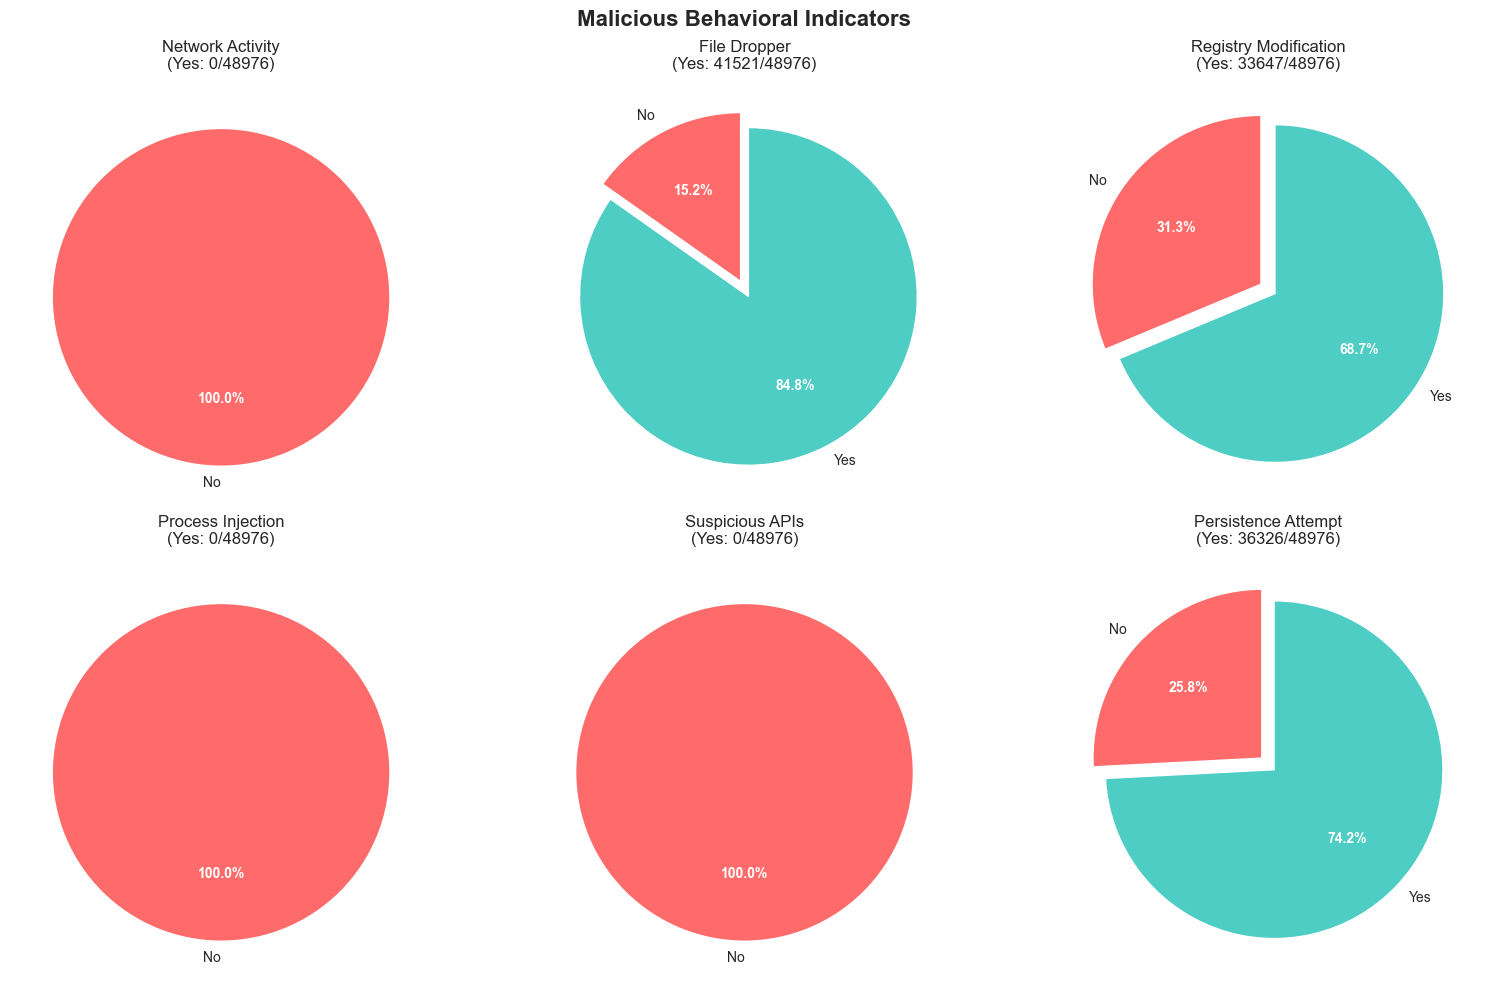

✓ Behavioral Indicators visualization complete


In [33]:
# Create visualization 2: Behavioral Indicators
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Malicious Behavioral Indicators', fontsize=16, fontweight='bold')

indicators = {
    'has_network': 'Network Activity',
    'drops_files': 'File Dropper',
    'registry_modification': 'Registry Modification',
    'process_injection': 'Process Injection',
    'has_suspicious_apis': 'Suspicious APIs',
    'persistence_attempt': 'Persistence Attempt'
}

for idx, (col, label) in enumerate(indicators.items()):
    ax = axes[idx // 3, idx % 3]
    
    # Get column data - handle duplicate columns by taking first match
    col_data = df_combined[col]
    if isinstance(col_data, pd.DataFrame):
        col_data = col_data.iloc[:, 0]  # Take first column if duplicates exist
    
    # Filter to only True/False values (drop NaN)
    col_data_clean = col_data.dropna()
    counts = col_data_clean.value_counts().sort_index()
    
    # Create appropriate labels based on actual boolean values
    labels = ['No' if v == False else 'Yes' for v in counts.index]
    colors = ['#ff6b6b', '#4ecdc4'] if len(counts) == 2 else ['#ff6b6b']
    
    wedges, texts, autotexts = ax.pie(counts, labels=labels, autopct='%1.1f%%',
                                       colors=colors, startangle=90, explode=[0.05]*len(counts))
    
    # Get count of True values
    true_count = int(counts[True]) if True in counts.index else 0
    ax.set_title(f'{label}\n(Yes: {true_count}/{len(df_combined)})')
    
    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)

plt.tight_layout()
plt.show()

print("✓ Behavioral Indicators visualization complete")

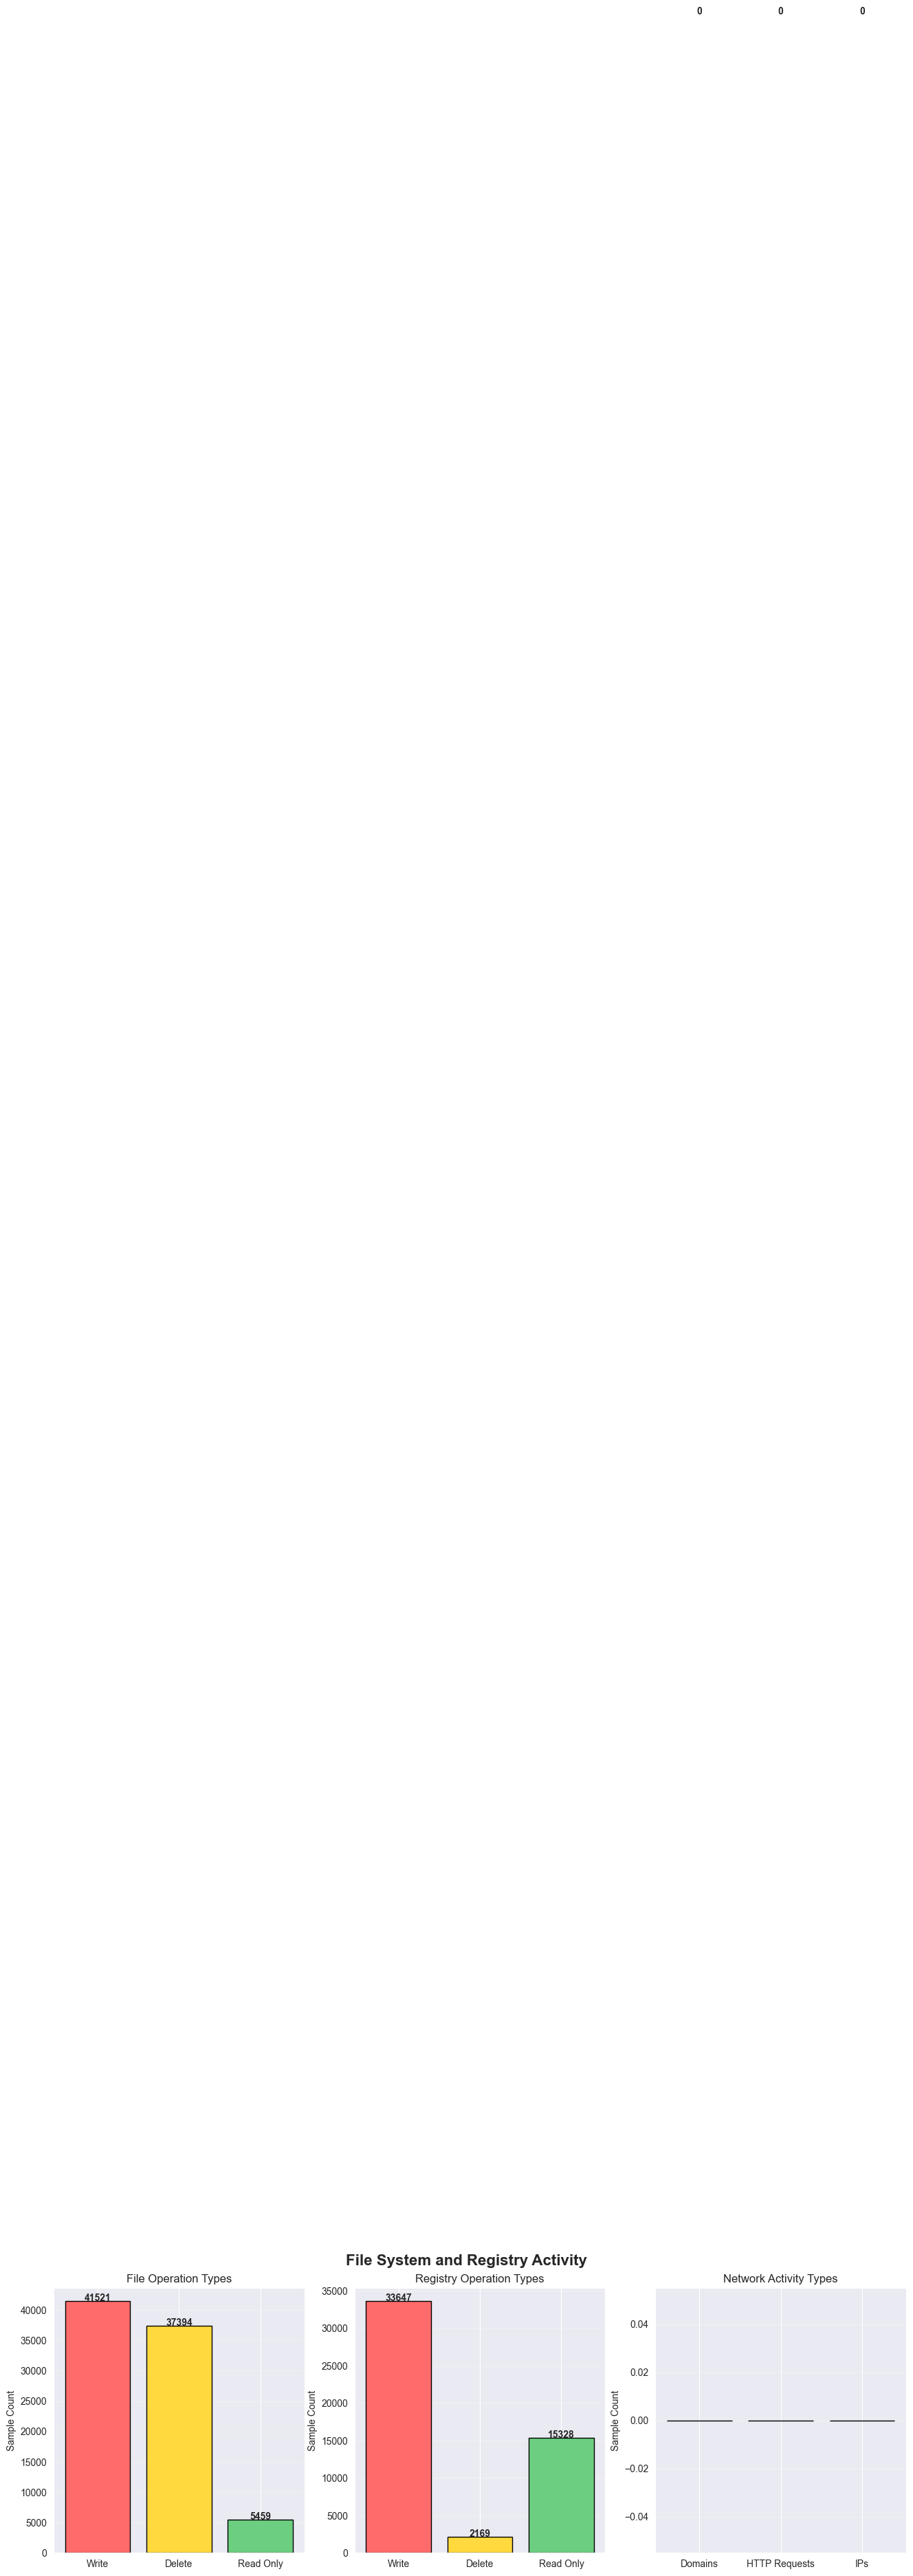

✓ File and Registry Activity visualization complete


In [34]:
# Create visualization 3: File and Registry Activity
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('File System and Registry Activity', fontsize=16, fontweight='bold')

# File operations
file_data = [
    (df_combined['num_write_files'] > 0).sum(),
    (df_combined['num_delete_files'] > 0).sum(),
    ((df_combined['num_files'] > 0) & (df_combined['num_write_files'] == 0) & (df_combined['num_delete_files'] == 0)).sum()
]
axes[0].bar(['Write', 'Delete', 'Read Only'], file_data, color=['#ff6b6b', '#ffd93d', '#6bcf7f'], edgecolor='black')
axes[0].set_ylabel('Sample Count')
axes[0].set_title('File Operation Types')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(file_data):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Registry operations
registry_data = [
    (df_combined['num_write_registry'] > 0).sum(),
    (df_combined['num_delete_registry'] > 0).sum(),
    ((df_combined['num_registry_keys'] > 0) & (df_combined['num_write_registry'] == 0) & (df_combined['num_delete_registry'] == 0)).sum()
]
axes[1].bar(['Write', 'Delete', 'Read Only'], registry_data, color=['#ff6b6b', '#ffd93d', '#6bcf7f'], edgecolor='black')
axes[1].set_ylabel('Sample Count')
axes[1].set_title('Registry Operation Types')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(registry_data):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Network activity
network_data = [
    (df_combined['num_domains'] > 0).sum(),
    (df_combined['num_http_requests'] > 0).sum(),
    (df_combined['num_ips'] > 0).sum()
]
axes[2].bar(['Domains', 'HTTP Requests', 'IPs'], network_data, color=['#4ecdc4', '#44a5c2', '#1d7874'], edgecolor='black')
axes[2].set_ylabel('Sample Count')
axes[2].set_title('Network Activity Types')
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(network_data):
    axes[2].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ File and Registry Activity visualization complete")

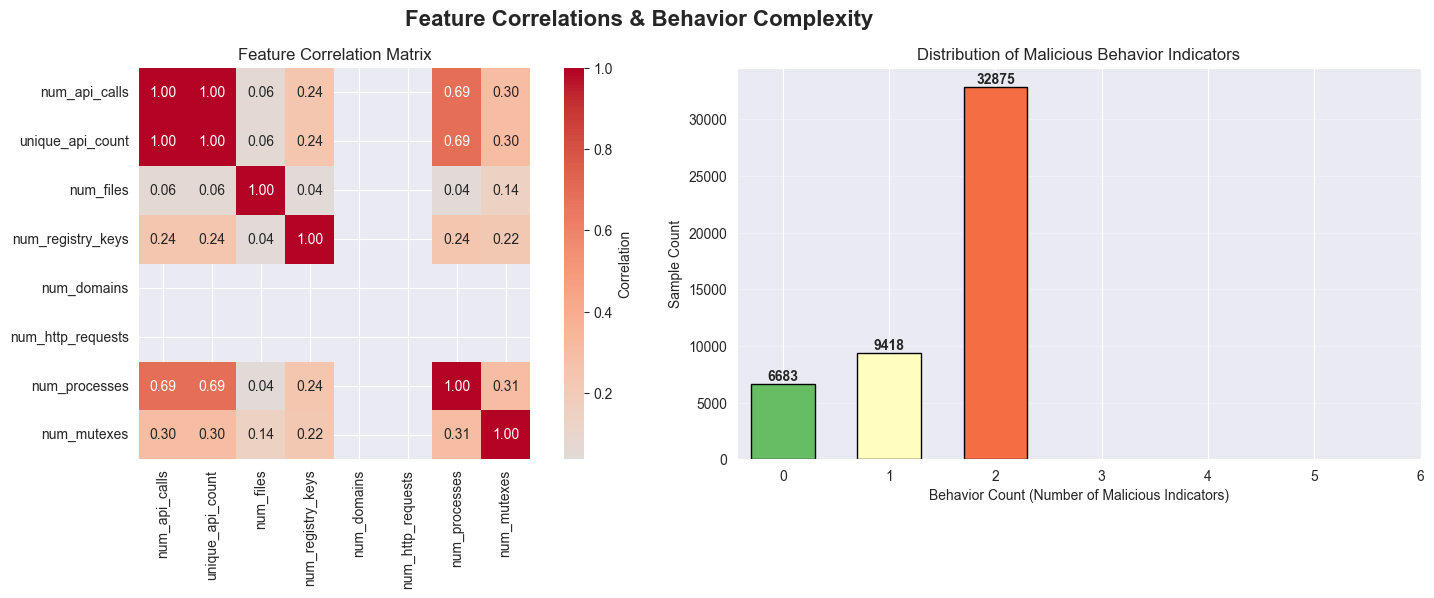

✓ Correlation and Behavior Count visualization complete


In [35]:
# Create visualization 4: Correlation Matrix and Behavior Count
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Correlations & Behavior Complexity', fontsize=16, fontweight='bold')

# Correlation heatmap
numeric_cols = ['num_api_calls', 'unique_api_count', 'num_files', 'num_registry_keys',
                'num_domains', 'num_http_requests', 'num_processes', 'num_mutexes']
correlation_matrix = df_combined[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=axes[0], cbar_kws={'label': 'Correlation'}, square=True)
axes[0].set_title('Feature Correlation Matrix')

# Behavior count distribution
behavior_count_dist = df_combined['behavior_count'].value_counts().sort_index()
colors_behav = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(behavior_count_dist)))
bars = axes[1].bar(behavior_count_dist.index, behavior_count_dist.values, color=colors_behav, edgecolor='black', width=0.6)
axes[1].set_xlabel('Behavior Count (Number of Malicious Indicators)')
axes[1].set_ylabel('Sample Count')
axes[1].set_title('Distribution of Malicious Behavior Indicators')
axes[1].set_xticks(range(0, 7))
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Correlation and Behavior Count visualization complete")

In [36]:
# Calculate mean domains for networked samples
has_network = df_combined['has_network']
if isinstance(has_network, pd.DataFrame):
    has_network = has_network.iloc[:, 0]
has_network_mask = has_network.astype(bool)
if has_network_mask.sum() > 0:
    num_domains = df_combined['num_domains']
    if isinstance(num_domains, pd.DataFrame):
        num_domains = num_domains.iloc[:, 0]
    print(f"   Mean domains per networked sample:{num_domains.loc[has_network_mask].mean():.1f}")

# 5. Suspicious API Analysis
print("\n5. SUSPICIOUS API ANALYSIS")
print("-" * 70)
susp_samples = df_combined['has_suspicious_apis'].sum()
print(f"   Samples with suspicious APIs:     {susp_samples}/{len(df_combined)} ({susp_samples/len(df_combined)*100:.1f}%)")
print(f"   Samples with process injection:   {df_combined['process_injection'].sum()}/{len(df_combined)} ({df_combined['process_injection'].sum()/len(df_combined)*100:.1f}%)")
print(f"   Samples with DLL/Hook activity:   {df_combined['dlopen_or_hook'].sum()}/{len(df_combined)} ({df_combined['dlopen_or_hook'].sum()/len(df_combined)*100:.1f}%)")
print(f"   Samples with shell execution:     {df_combined['shell_execute'].sum()}/{len(df_combined)} ({df_combined['shell_execute'].sum()/len(df_combined)*100:.1f}%)")

# 6. Advanced Threats
print("\n6. ADVANCED THREAT PATTERNS")
print("-" * 70)
dropper = df_combined['has_file_dropper'].sum()
c2 = df_combined['has_c2_communication'].sum()
persist = df_combined['persistence_attempt'].sum()
print(f"   File dropper samples:             {dropper}/{len(df_combined)} ({dropper/len(df_combined)*100:.1f}%)")
print(f"   C2 communication patterns:        {c2}/{len(df_combined)} ({c2/len(df_combined)*100:.1f}%)")
print(f"   Persistence attempts:             {persist}/{len(df_combined)} ({persist/len(df_combined)*100:.1f}%)")

# 7. Malicious Behavior Score
print("\n7. MALICIOUS BEHAVIOR COMPLEXITY")
print("-" * 70)
print(f"   Mean behavior count:              {df_combined['behavior_count'].mean():.1f}")
print(f"   Samples with 0 indicators:        {(df_combined['behavior_count'] == 0).sum()}/{len(df_combined)}")
print(f"   Samples with 1-2 indicators:      {((df_combined['behavior_count'] >= 1) & (df_combined['behavior_count'] <= 2)).sum()}/{len(df_combined)}")
print(f"   Samples with 3-4 indicators:      {((df_combined['behavior_count'] >= 3) & (df_combined['behavior_count'] <= 4)).sum()}/{len(df_combined)}")
print(f"   Samples with 5-6 indicators:      {((df_combined['behavior_count'] >= 5) & (df_combined['behavior_count'] <= 6)).sum()}/{len(df_combined)}")

print("\n" + "="*70)


5. SUSPICIOUS API ANALYSIS
----------------------------------------------------------------------
   Samples with suspicious APIs:     0/48976 (0.0%)
   Samples with process injection:   0/48976 (0.0%)
   Samples with DLL/Hook activity:   0/48976 (0.0%)
   Samples with shell execution:     0/48976 (0.0%)

6. ADVANCED THREAT PATTERNS
----------------------------------------------------------------------
   File dropper samples:             0/48976 (0.0%)
   C2 communication patterns:        0/48976 (0.0%)
   Persistence attempts:             36326/48976 (74.2%)

7. MALICIOUS BEHAVIOR COMPLEXITY
----------------------------------------------------------------------
   Mean behavior count:              1.5
   Samples with 0 indicators:        6683/48976
   Samples with 1-2 indicators:      42293/48976
   Samples with 3-4 indicators:      0/48976
   Samples with 5-6 indicators:      0/48976



------------------------------------------------------------
## SECTION 8: Automated Signature Generation
------------------------------------------------------------

Generate behavioral signatures based on detected patterns for CAPEv2:

In [37]:
def create_behavior_signature(report_hash: str, features: dict, sig_features: dict, sample_idx: int, 
                               family: str = 'unknown', malware_type: str = 'unknown') -> dict:
    """
    Generate a behavioral signature for a single malware sample.
    
    This creates a human-readable and machine-parseable signature that describes
    the behavioral characteristics detected in the CAPEv2 analysis.
    
    Args:
        report_hash: Hash identifier of the report
        features: Dictionary of extracted features
        sig_features: Dictionary of signature-specific features
        sample_idx: Index of the sample
        family: Malware family classification
        malware_type: Malware type classification
    
    Returns:
        Dictionary with signature components
    """
    
    signature = {
        'report_hash': report_hash,
        'signature_id': f'BEH_{sample_idx:06d}',
        'family': family,
        'malware_type': malware_type,
        'version': '1.0',
        'type': 'behavioral',
        'detection_methods': [],
        'rules': [],
        'mitre_techniques': [],
        'threat_level': 'unknown'
    }
    
    # Determine threat level
    behavior_count = sum([
        sig_features['has_network'],
        sig_features['drops_files'],
        sig_features['registry_modification'],
        sig_features['process_injection'],
        sig_features['dlopen_or_hook'],
        sig_features['shell_execute']
    ])
    
    if behavior_count == 0:
        signature['threat_level'] = 'benign'
    elif behavior_count <= 2:
        signature['threat_level'] = 'low'
    elif behavior_count <= 4:
        signature['threat_level'] = 'medium'
    else:
        signature['threat_level'] = 'high'
    
    # Build detection rules based on observed behaviors
    
    # Rule 1: API Call Pattern Detection
    if sig_features['suspicious_apis']:
        api_rule = {
            'name': 'Suspicious_API_Call_Pattern',
            'condition': f"any of ({len(sig_features['suspicious_apis'])} suspicious APIs)",
            'apis': sig_features['suspicious_apis'][:10],  # Top 10 suspicious APIs
            'severity': 'high',
            'description': 'Detection of known malicious API calls'
        }
        signature['rules'].append(api_rule)
        signature['detection_methods'].append('API_PATTERN')
        signature['mitre_techniques'].append('T1106')  # Native API
    
    # Rule 2: Process Injection
    if sig_features['process_injection']:
        injection_rule = {
            'name': 'Process_Injection',
            'apis': ['WriteProcessMemory', 'VirtualAllocEx', 'CreateRemoteThread'],
            'severity': 'critical',
            'description': 'Process injection capability detected'
        }
        signature['rules'].append(injection_rule)
        signature['detection_methods'].append('PROCESS_INJECTION')
        signature['mitre_techniques'].extend(['T1055', 'T1055.001'])  # Process Injection
    
    # Rule 3: File Dropper Pattern
    if sig_features['has_file_dropper']:
        dropper_rule = {
            'name': 'File_Dropper',
            'file_write_count': features['files'].__len__(),
            'network_indicators': len(features['domains']) + len(features['http_requests']),
            'severity': 'high',
            'description': 'Sample downloads and executes files (dropper behavior)'
        }
        signature['rules'].append(dropper_rule)
        signature['detection_methods'].append('FILE_DROPPER')
        signature['mitre_techniques'].extend(['T1105', 'T1204.002'])  # Ingress Tool Transfer
    
    # Rule 4: Network Communication (C2)
    if sig_features['has_c2_communication']:
        c2_rule = {
            'name': 'C2_Communication',
            'domains': features['domains'][:5],
            'http_endpoints': features['http_requests'][:3],
            'severity': 'critical',
            'description': 'Command and Control communication pattern'
        }
        signature['rules'].append(c2_rule)
        signature['detection_methods'].append('C2_COMMUNICATION')
        signature['mitre_techniques'].extend(['T1071', 'T1071.001'])  # Application Layer Protocol
    
    # Rule 5: Persistence
    if sig_features['persistence_attempt']:
        persistence_rule = {
            'name': 'Persistence_Mechanism',
            'registry_modifications': sum(1 for r, op in features['registry'] if op == 'write'),
            'severity': 'high',
            'description': 'Potential persistence mechanism (registry modification)'
        }
        signature['rules'].append(persistence_rule)
        signature['detection_methods'].append('PERSISTENCE')
        signature['mitre_techniques'].extend(['T1547', 'T1547.001'])  # Boot or Logon Autostart Execution
    
    # Rule 6: DLL Loading / Hook Installation
    if sig_features['dlopen_or_hook']:
        injection_rule = {
            'name': 'DLL_Loading_Hook',
            'apis': ['LoadLibraryA', 'LoadLibraryW', 'SetWindowsHookEx'],
            'severity': 'medium',
            'description': 'Suspicious DLL loading or hook installation'
        }
        signature['rules'].append(injection_rule)
        signature['detection_methods'].append('DLL_INJECTION')
        signature['mitre_techniques'].extend(['T1055.001'])
    
    # Rule 7: Privilege Escalation Indicators
    if any(api in features['api_calls'] for api in ['CreateProcessAsUserA', 'CreateProcessAsUserW']):
        priv_esc_rule = {
            'name': 'Privilege_Escalation',
            'apis': ['CreateProcessAsUserA', 'CreateProcessAsUserW'],
            'severity': 'high',
            'description': 'Privilege escalation attempt detected'
        }
        signature['rules'].append(priv_esc_rule)
        signature['mitre_techniques'].append('T1134')  # Access Token Manipulation
    
    # Map MITRE techniques to tactic
    mitre_mapping = {
        'T1106': 'Execution',
        'T1055': 'Defense Evasion',
        'T1055.001': 'Defense Evasion',
        'T1105': 'Command and Control',
        'T1204.002': 'Initial Access',
        'T1071': 'Command and Control',
        'T1071.001': 'Command and Control',
        'T1547': 'Persistence',
        'T1547.001': 'Persistence',
        'T1134': 'Privilege Escalation'
    }
    
    # Add summary
    signature['summary'] = {
        'rule_count': len(signature['rules']),
        'detection_methods_count': len(signature['detection_methods']),
        'top_apis': sig_features['top_apis'][:5],
        'network_indicators': len(features['domains']) + len(features['http_requests']),
        'file_operations': len(features['files']),
        'registry_operations': len(features['registry']),
        'api_calls_total': len(features['api_calls']),
        'unique_apis': len(features['api_freq'])
    }
    
    return signature


# Generate signatures for all samples
print("Generating behavioral signatures for all samples...")
all_signatures = []

for idx, (report_hash, features, sig_features) in enumerate(tqdm(zip(report_hashes, all_features, signature_features_list), 
                                                                   total=len(report_hashes),
                                                                   desc="Signature generation")):
    # Get family and type labels from preprocessed data
    family = hash_to_family.get(report_hash, 'unknown')
    malware_type = hash_to_type.get(report_hash, 'unknown')
    signature = create_behavior_signature(report_hash, features, sig_features, idx, family, malware_type)
    all_signatures.append(signature)

print(f"\n✓ Generated {len(all_signatures)} behavioral signatures")

Generating behavioral signatures for all samples...


Signature generation: 100%|██████████| 48976/48976 [00:03<00:00, 15025.37it/s]


✓ Generated 48976 behavioral signatures


In [38]:
# Analyze signature characteristics
print("\n" + "="*70)
print("SIGNATURE ANALYSIS")
print("="*70)

# Count threat levels
threat_counts = {}
for sig in all_signatures:
    level = sig['threat_level']
    threat_counts[level] = threat_counts.get(level, 0) + 1

print("\nThreat Level Distribution:")
for level, count in sorted(threat_counts.items()):
    pct = count / len(all_signatures) * 100
    print(f"  {level.upper():10s}: {count:4d} ({pct:5.1f}%)")

# Detection method statistics
detection_method_counts = defaultdict(int)
for sig in all_signatures:
    for method in sig['detection_methods']:
        detection_method_counts[method] += 1

print("\nDetection Methods Frequency:")
for method in sorted(detection_method_counts.keys(), key=lambda x: detection_method_counts[x], reverse=True):
    count = detection_method_counts[method]
    pct = count / len(all_signatures) * 100
    print(f"  {method:25s}: {count:4d} ({pct:5.1f}%)")

# Rule statistics
rule_counts = [len(sig['rules']) for sig in all_signatures]
print(f"\nRule Statistics:")
print(f"  Mean rules per signature:  {np.mean(rule_counts):.1f}")
print(f"  Median rules:              {np.median(rule_counts):.0f}")
print(f"  Max rules:                 {np.max(rule_counts)}")
print(f"  Min rules:                 {np.min(rule_counts)}")

# MITRE Technique coverage
all_mitre = set()
for sig in all_signatures:
    all_mitre.update(sig['mitre_techniques'])

print(f"\nMITRE ATT&CK Coverage:")
print(f"  Unique techniques mapped:  {len(all_mitre)}")
print(f"  Techniques: {sorted(all_mitre)}")

print("\n" + "="*70)


SIGNATURE ANALYSIS

Threat Level Distribution:
  BENIGN    : 6683 ( 13.6%)
  LOW       : 42293 ( 86.4%)

Detection Methods Frequency:
  PERSISTENCE              : 36326 ( 74.2%)

Rule Statistics:
  Mean rules per signature:  0.7
  Median rules:              1
  Max rules:                 1
  Min rules:                 0

MITRE ATT&CK Coverage:
  Unique techniques mapped:  2
  Techniques: ['T1547', 'T1547.001']



In [39]:
# Display example signatures
print("\n" + "="*70)
print("EXAMPLE SIGNATURES (Top 3 by threat level)")
print("="*70)

# Find high threat samples
high_threat = [sig for sig in all_signatures if sig['threat_level'] in ['high', 'critical']]
high_threat.sort(key=lambda x: (x['threat_level'] == 'critical', len(x['rules'])), reverse=True)

for idx, sig in enumerate(high_threat[:3]):
    print(f"\n\n{'#'*70}")
    print(f"SIGNATURE #{idx+1}: {sig['signature_id']}")
    print(f"{'#'*70}")
    print(f"Report Hash:     {sig['report_hash'][:32]}...")
    print(f"Threat Level:    {sig['threat_level'].upper()}")
    print(f"Version:         {sig['version']}")
    print(f"Type:            {sig['type']}")
    print(f"\nDetection Methods ({len(sig['detection_methods'])}):")
    for method in sig['detection_methods']:
        print(f"  • {method}")
    
    print(f"\nDetection Rules ({len(sig['rules'])}):")
    for rule in sig['rules']:
        print(f"\n  Rule: {rule['name']}")
        print(f"    Severity:    {rule['severity']}")
        print(f"    Description: {rule['description']}")
        if 'apis' in rule:
            print(f"    APIs ({len(rule['apis'])}): {', '.join(rule['apis'][:3])}{'...' if len(rule['apis']) > 3 else ''}")
        if 'file_write_count' in rule:
            print(f"    File Operations: {rule['file_write_count']}")
        if 'network_indicators' in rule:
            print(f"    Network Indicators: {rule['network_indicators']}")
    
    print(f"\nMITRE ATT&CK Techniques:")
    for technique in sig['mitre_techniques']:
        print(f"  • {technique}")
    
    print(f"\nSummary Statistics:")
    summary = sig['summary']
    print(f"  Total API Calls:       {summary['api_calls_total']}")
    print(f"  Unique APIs:           {summary['unique_apis']}")
    print(f"  File Operations:       {summary['file_operations']}")
    print(f"  Registry Operations:   {summary['registry_operations']}")
    print(f"  Network Indicators:    {summary['network_indicators']}")

print(f"\n{'='*70}\n")


EXAMPLE SIGNATURES (Top 3 by threat level)




In [40]:
# Save signatures to files
print("\n" + "="*70)
print("SAVING SIGNATURES TO DISK")
print("="*70)

# 1. Save detailed signatures as JSON
signatures_json_path = PROCESSED_DIR / 'behavioral_signatures.json'
with open(signatures_json_path, 'w') as f:
    json.dump(all_signatures, f, indent=2)
print(f"\n✓ Saved detailed signatures to: {signatures_json_path}")

# 2. Create signature summary DataFrame
signature_summary = []
for sig in all_signatures:
    summary_row = {
        'signature_id': sig['signature_id'],
        'report_hash': sig['report_hash'],
        'family': sig.get('family', 'unknown'),
        'malware_type': sig.get('malware_type', 'unknown'),
        'threat_level': sig['threat_level'],
        'rule_count': sig['summary']['rule_count'],
        'detection_methods': ','.join(sig['detection_methods']),
        'api_calls_total': sig['summary']['api_calls_total'],
        'unique_apis': sig['summary']['unique_apis'],
        'file_operations': sig['summary']['file_operations'],
        'registry_operations': sig['summary']['registry_operations'],
        'network_indicators': sig['summary']['network_indicators'],
        'mitre_techniques': ','.join(sig['mitre_techniques'])
    }
    signature_summary.append(summary_row)

df_signatures = pd.DataFrame(signature_summary)
signatures_csv_path = PROCESSED_DIR / 'signature_summary.csv'
df_signatures.to_csv(signatures_csv_path, index=False)
print(f"✓ Saved signature summary to: {signatures_csv_path}")

# 3. Create rule-based detection patterns
rule_patterns = {
    'process_injection': {
        'description': 'Samples exhibiting process injection behaviors',
        'count': sum(1 for sig in all_signatures if 'Process_Injection' in [r['name'] for r in sig['rules']])
    },
    'c2_communication': {
        'description': 'Samples with C2 communication patterns',
        'count': sum(1 for sig in all_signatures if 'C2_Communication' in [r['name'] for r in sig['rules']])
    },
    'file_dropper': {
        'description': 'File dropper samples (downloads and executes files)',
        'count': sum(1 for sig in all_signatures if 'File_Dropper' in [r['name'] for r in sig['rules']])
    },
    'persistence': {
        'description': 'Samples attempting persistence mechanisms',
        'count': sum(1 for sig in all_signatures if 'Persistence_Mechanism' in [r['name'] for r in sig['rules']])
    },
    'privilege_escalation': {
        'description': 'Samples attempting privilege escalation',
        'count': sum(1 for sig in all_signatures if 'Privilege_Escalation' in [r['name'] for r in sig['rules']])
    }
}

patterns_json_path = PROCESSED_DIR / 'detection_patterns.json'
with open(patterns_json_path, 'w') as f:
    json.dump(rule_patterns, f, indent=2)
print(f"✓ Saved detection patterns to: {patterns_json_path}")

print(f"\n" + "="*70)
print("SIGNATURE GENERATION COMPLETE")
print("="*70)
print(f"\nGenerated {len(all_signatures)} behavioral signatures")
print(f"\nOutput files:")
print(f"  1. {signatures_json_path}")
print(f"  2. {signatures_csv_path}")
print(f"  3. {patterns_json_path}")
print(f"  4. {output_path} (features)")
print(f"  5. {detail_output} (details)")
print("\n" + "="*70)


SAVING SIGNATURES TO DISK

✓ Saved detailed signatures to: C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\behavioral_signatures.json
✓ Saved signature summary to: C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\signature_summary.csv
✓ Saved detection patterns to: C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\detection_patterns.json

SIGNATURE GENERATION COMPLETE

Generated 48976 behavioral signatures

Output files:
  1. C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\behavioral_signatures.json
  2. C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\signature_summary.csv
  3. C:\Users\USER\Desktop\S7\malware_analysis\Automated-Dynamic-Analysis-Signature-Generation\data\processed\detection_patterns.json
  4

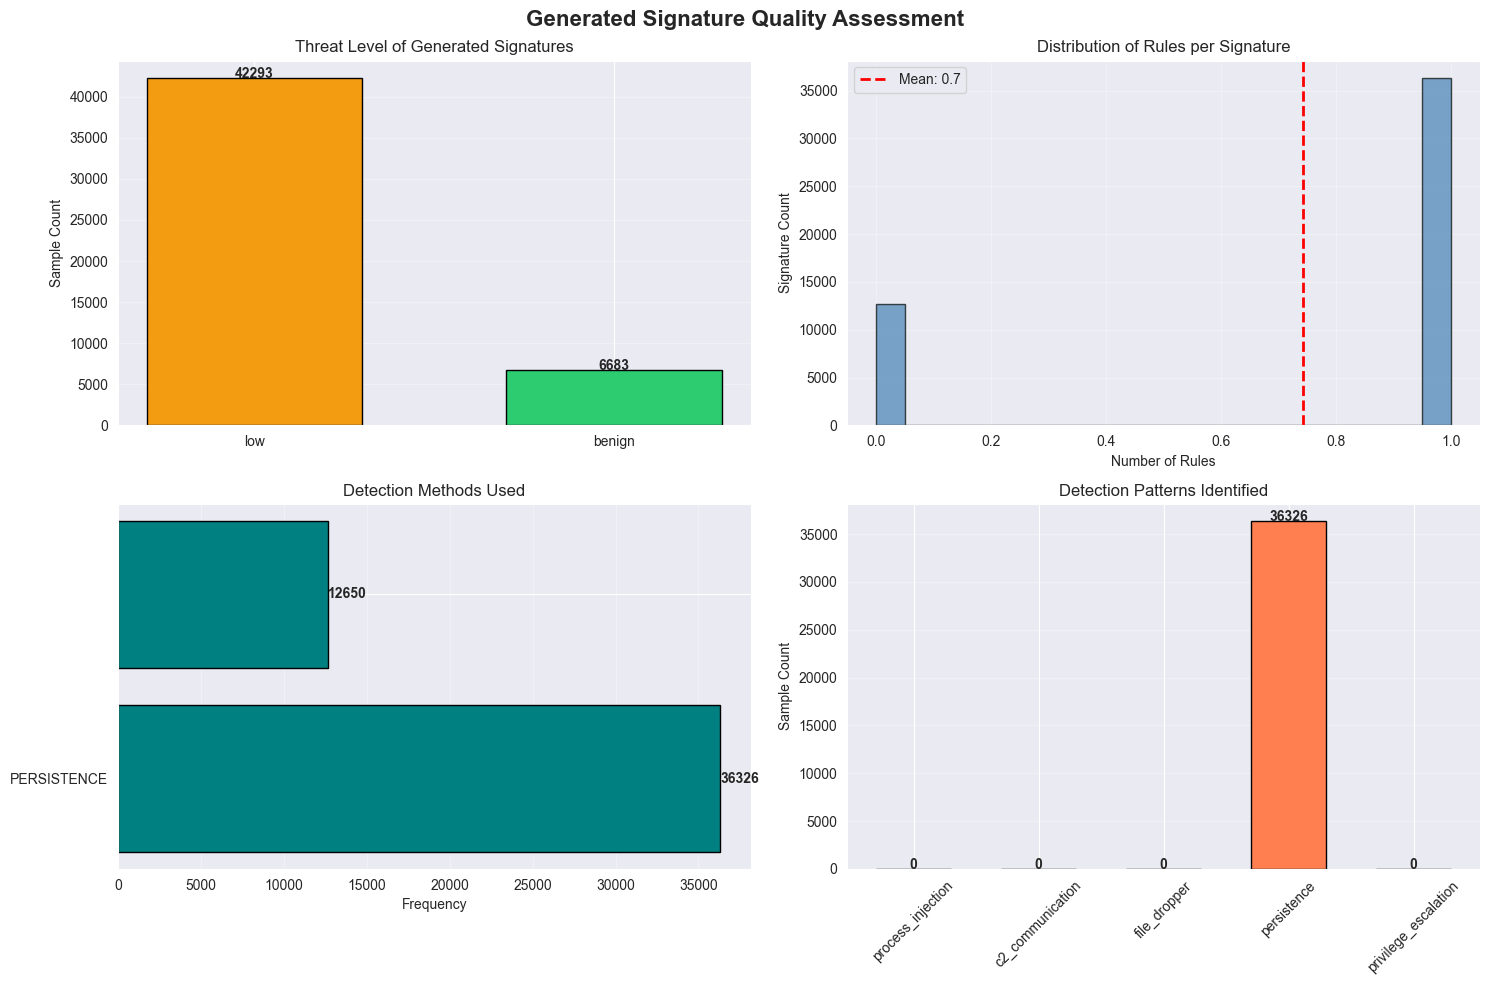

✓ Signature Quality Assessment visualization complete


In [41]:
# Final visualization: Signature Quality Assessment
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Generated Signature Quality Assessment', fontsize=16, fontweight='bold')

# 1. Threat level distribution
threat_data = df_signatures['threat_level'].value_counts()
colors_threat = {'benign': '#2ecc71', 'low': '#f39c12', 'medium': '#e67e22', 'high': '#e74c3c', 'critical': '#c0392b'}
threat_colors = [colors_threat.get(level, '#95a5a6') for level in threat_data.index]
axes[0, 0].bar(threat_data.index, threat_data.values, color=threat_colors, edgecolor='black', width=0.6)
axes[0, 0].set_ylabel('Sample Count')
axes[0, 0].set_title('Threat Level of Generated Signatures')
axes[0, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(threat_data.values):
    axes[0, 0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# 2. Rules per signature
axes[0, 1].hist(df_signatures['rule_count'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Number of Rules')
axes[0, 1].set_ylabel('Signature Count')
axes[0, 1].set_title('Distribution of Rules per Signature')
axes[0, 1].axvline(df_signatures['rule_count'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_signatures["rule_count"].mean():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Detection methods used
detection_methods = []
for methods_str in df_signatures['detection_methods']:
    if pd.notna(methods_str):
        detection_methods.extend(methods_str.split(','))

method_counts = pd.Series(detection_methods).value_counts()
axes[1, 0].barh(method_counts.index, method_counts.values, color='teal', edgecolor='black')
axes[1, 0].set_xlabel('Frequency')
axes[1, 0].set_title('Detection Methods Used')
axes[1, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(method_counts.values):
    axes[1, 0].text(v + 1, i, str(v), va='center', fontweight='bold')

# 4. Detection pattern summary
pattern_names = list(rule_patterns.keys())
pattern_counts = [rule_patterns[p]['count'] for p in pattern_names]
axes[1, 1].bar(pattern_names, pattern_counts, color='coral', edgecolor='black', width=0.6)
axes[1, 1].set_ylabel('Sample Count')
axes[1, 1].set_title('Detection Patterns Identified')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(pattern_counts):
    axes[1, 1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Signature Quality Assessment visualization complete")

In [42]:
# Helper function to safely sum columns with potential duplicates
def safe_int_sum(col):
    """Safely convert column sum to int, handling DataFrames with duplicate columns"""
    if isinstance(col, pd.DataFrame):
        col = col.iloc[:, 0]
    return int(col.sum())

print("\n2. DATA ANALYSIS & VISUALIZATION")
print("   " + "-"*66)
print(f"   ✓ API call statistics (mean: {df_combined['num_api_calls'].mean():.1f}, max: {df_combined['num_api_calls'].max()})")
drops_files_count = safe_int_sum(df_combined['drops_files'])
print(f"   ✓ File dropper detection: {drops_files_count} samples ({drops_files_count/len(df_combined)*100:.1f}%)")
registry_mod_count = safe_int_sum(df_combined['registry_modification'])
print(f"   ✓ Registry modification: {registry_mod_count} samples ({registry_mod_count/len(df_combined)*100:.1f}%)")
network_count = safe_int_sum(df_combined['has_network'])
print(f"   ✓ Network activity: {network_count} samples ({network_count/len(df_combined)*100:.1f}%)")
injection_count = safe_int_sum(df_combined['process_injection'])
print(f"   ✓ Process injection: {injection_count} samples ({injection_count/len(df_combined)*100:.1f}%)")
suspicious_count = safe_int_sum(df_combined['has_suspicious_apis'])
print(f"   ✓ Suspicious APIs: {suspicious_count} samples ({suspicious_count/len(df_combined)*100:.1f}%)")


2. DATA ANALYSIS & VISUALIZATION
   ------------------------------------------------------------------
   ✓ API call statistics (mean: 175.4, max: 1969)
   ✓ File dropper detection: 41521 samples (84.8%)
   ✓ Registry modification: 33647 samples (68.7%)
   ✓ Network activity: 0 samples (0.0%)
   ✓ Process injection: 0 samples (0.0%)
   ✓ Suspicious APIs: 0 samples (0.0%)
